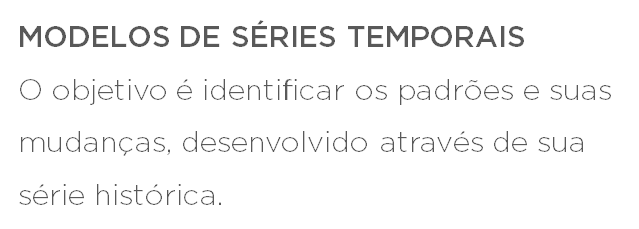

 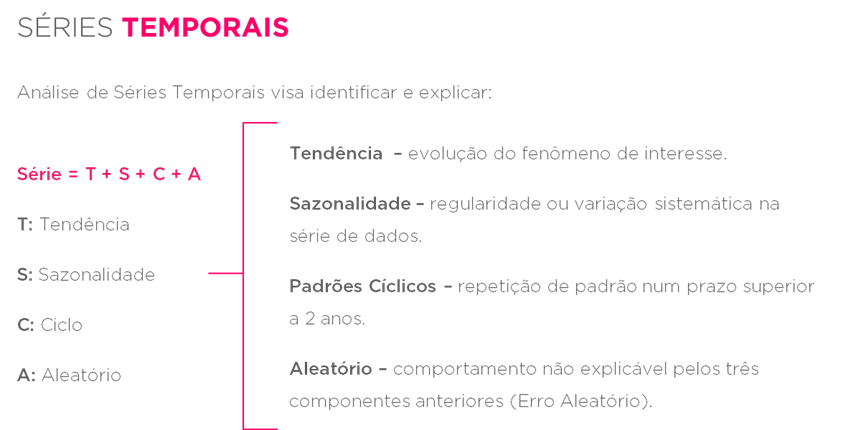

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

from datetime import datetime

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [3]:
df = pd.read_csv('Faturamento_v2.csv', sep=";")

In [5]:
df.head()

,Ano_Mes,Faturamento
0,2021-01-01,43484
1,2021-02-01,45859
2,2021-03-01,56254
3,2021-04-01,58224
4,2021-05-01,75403


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ano_Mes      48 non-null     object
 1   Faturamento  48 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 900.0+ bytes


    Verifiquem que a variável Ano_Mes foi lida no formato string

    Vamos transformá-la em formato data

In [9]:
df['Ano_Mes'] = pd.to_datetime(df['Ano_Mes'] ,format='%Y-%m-%d')


In [11]:
df.dtypes

Ano_Mes        datetime64[ns]
Faturamento             int64
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Ano_Mes      48 non-null     datetime64[ns]
 1   Faturamento  48 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 900.0 bytes


    Verifiquem que o indice da base df é um índice de 0 a 47

    Vamos fazer que o tempo (a variável que está no formato data) seja o índice

In [15]:
df.index

RangeIndex(start=0, stop=48, step=1)

In [17]:
df.set_index("Ano_Mes", inplace=True)

In [19]:
print (df.dtypes)

Faturamento    int64
dtype: object


In [21]:
print (df)

            Faturamento
Ano_Mes                
2021-01-01        43484
2021-02-01        45859
2021-03-01        56254
2021-04-01        58224
2021-05-01        75403
2021-06-01        61255
2021-07-01        65601
2021-08-01        80099
2021-09-01        75017
2021-10-01        87932
2021-11-01        95266
2021-12-01        79175
2022-01-01        54085
2022-02-01        63808
2022-03-01        66330
2022-04-01        72442
2022-05-01        83072
2022-06-01        71321
2022-07-01        70095
2022-08-01        99071
2022-09-01       103100
2022-10-01        98380
2022-11-01       113751
2022-12-01        84933
2023-01-01        65096
2023-02-01        72546
2023-03-01        93375
2023-04-01        88548
2023-05-01        83629
2023-06-01        84438
2023-07-01        97445
2023-08-01       114500
2023-09-01       127127
2023-10-01       122751
2023-11-01       136693
2023-12-01       111804
2024-01-01        78111
2024-02-01        87265
2024-03-01       102945
2024-04-01      

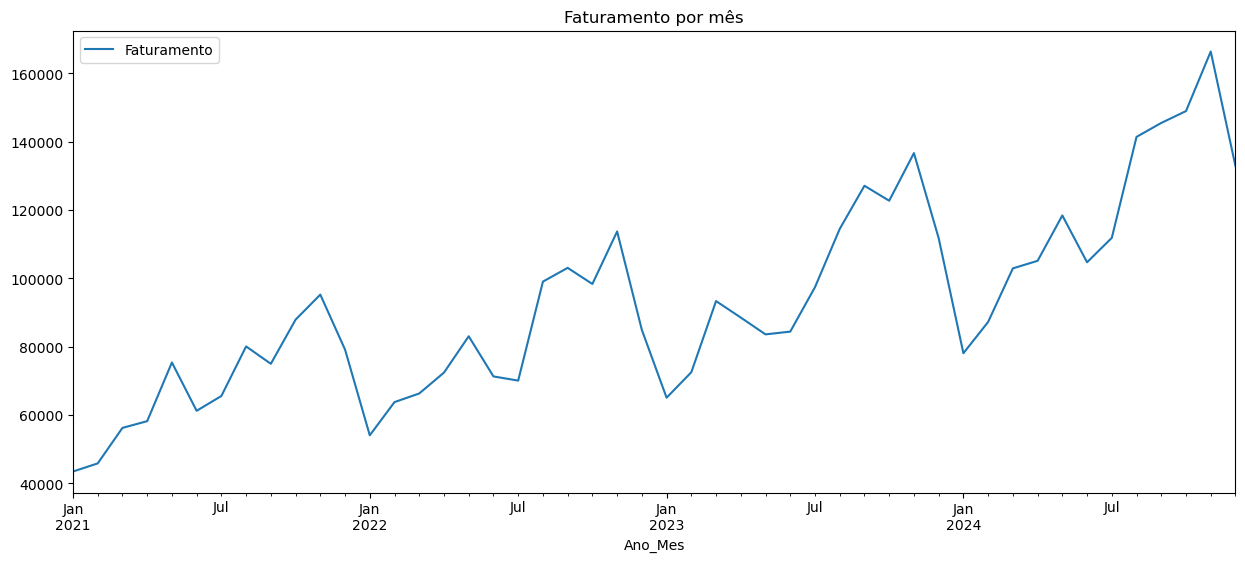

In [23]:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


df[['Faturamento']].plot(title='Faturamento por mês');


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2021-01-01 to 2024-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Faturamento  48 non-null     int64
dtypes: int64(1)
memory usage: 768.0 bytes


In [27]:
print(df.shape)


(48, 1)


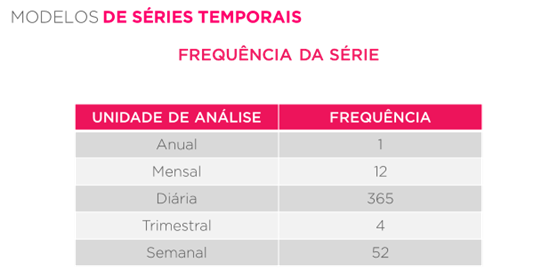

#### quando estamos interessados em avaliar se o valor no tempo t tem correlação com o valor em períodos anteriores

In [29]:
# correlação entre o tempo t e temp t-1

correlacao = df['Faturamento'].corr(df['Faturamento'].shift(1))

print('Correlação da mesma série periodo t e periodo t-1:', correlacao)


Correlação da mesma série periodo t e periodo t-1: 0.8518344615109071


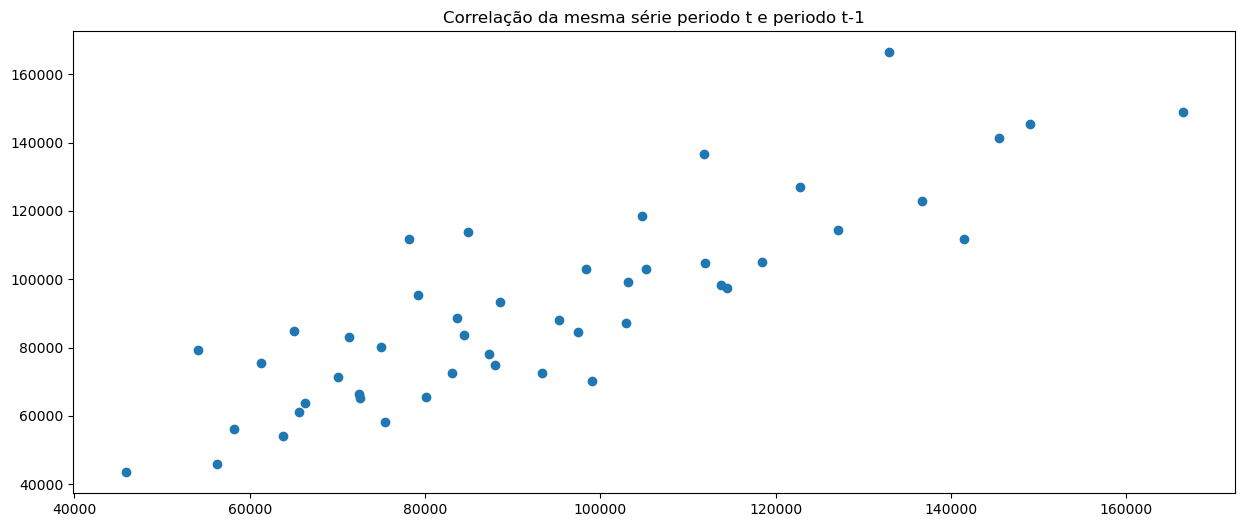

In [31]:
plt.scatter(df.Faturamento,df['Faturamento'].shift(1))
plt.title('Correlação da mesma série periodo t e periodo t-1')
plt.show()

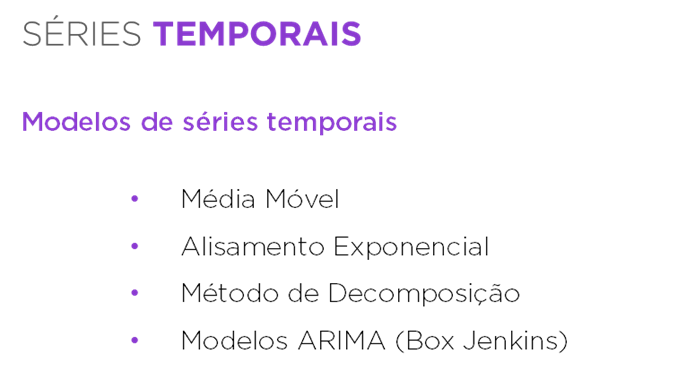

## Média Móvel

### Criar a variável Média Móvel de ordem 2

In [33]:
df['Media_Movel_2'] =df['Faturamento'].rolling(window = 2).mean()
df.head(50)

,Faturamento,Media_Movel_2
Ano_Mes,,
2021-01-01,43484,NaN
2021-02-01,45859,44671.5
2021-03-01,56254,51056.5
2021-04-01,58224,57239.0
2021-05-01,75403,66813.5
2021-06-01,61255,68329.0
2021-07-01,65601,63428.0
2021-08-01,80099,72850.0
2021-09-01,75017,77558.0


In [35]:
df['Tempo'] = range(0,len(df.index.values))

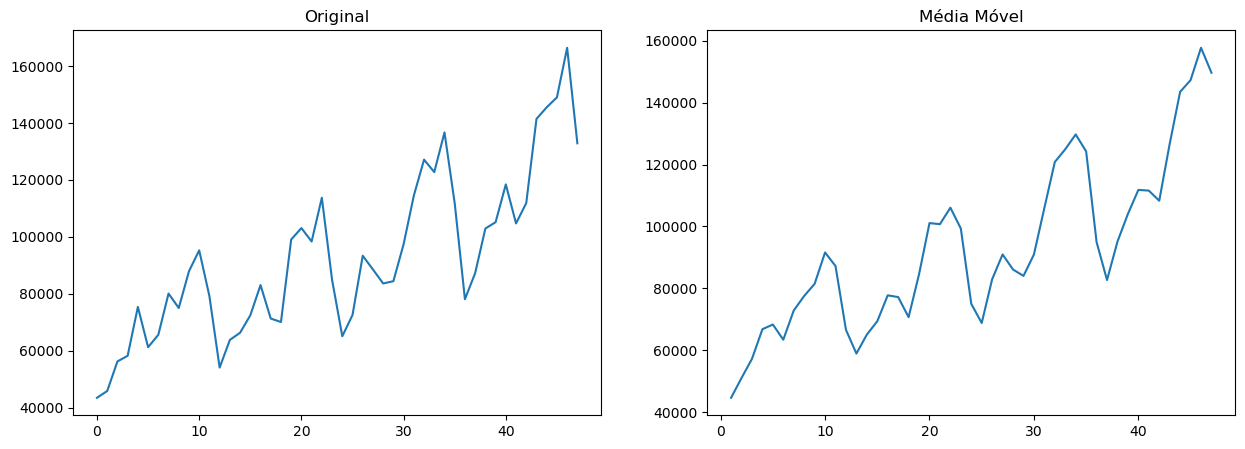

In [37]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5));
axes[0].plot('Tempo', 'Faturamento', data = df);
axes[0].set_title('Original');

axes[1].plot('Tempo', 'Media_Movel_2', data = df);
axes[1].set_title('Média Móvel');

### Gráfico da série Faturamento  e Faturamento  suavizada(2)

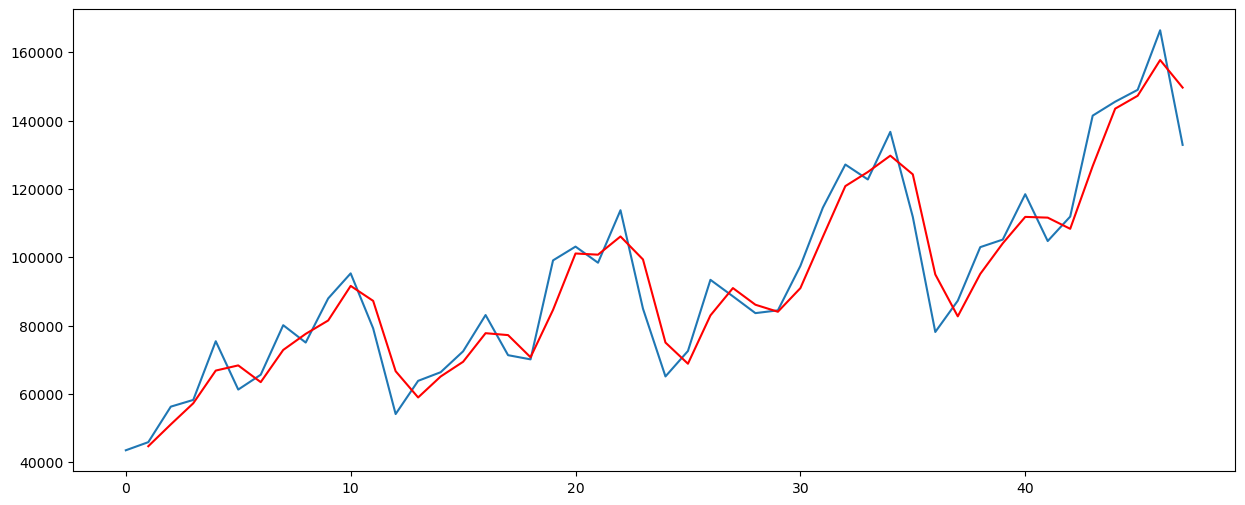

In [39]:
plt.plot('Tempo', 'Faturamento', data = df);
plt.plot('Tempo', 'Media_Movel_2', color='red', data = df);

In [41]:
df['Media_Movel_3'] = df['Faturamento'].rolling(window = 3).mean()
df.head(50)

,Faturamento,Media_Movel_2,Tempo,Media_Movel_3
Ano_Mes,,,,
2021-01-01,43484,NaN,0,NaN
2021-02-01,45859,44671.5,1,NaN
2021-03-01,56254,51056.5,2,48532.333333
2021-04-01,58224,57239.0,3,53445.666667
2021-05-01,75403,66813.5,4,63293.666667
2021-06-01,61255,68329.0,5,64960.666667
2021-07-01,65601,63428.0,6,67419.666667
2021-08-01,80099,72850.0,7,68985.000000
2021-09-01,75017,77558.0,8,73572.333333


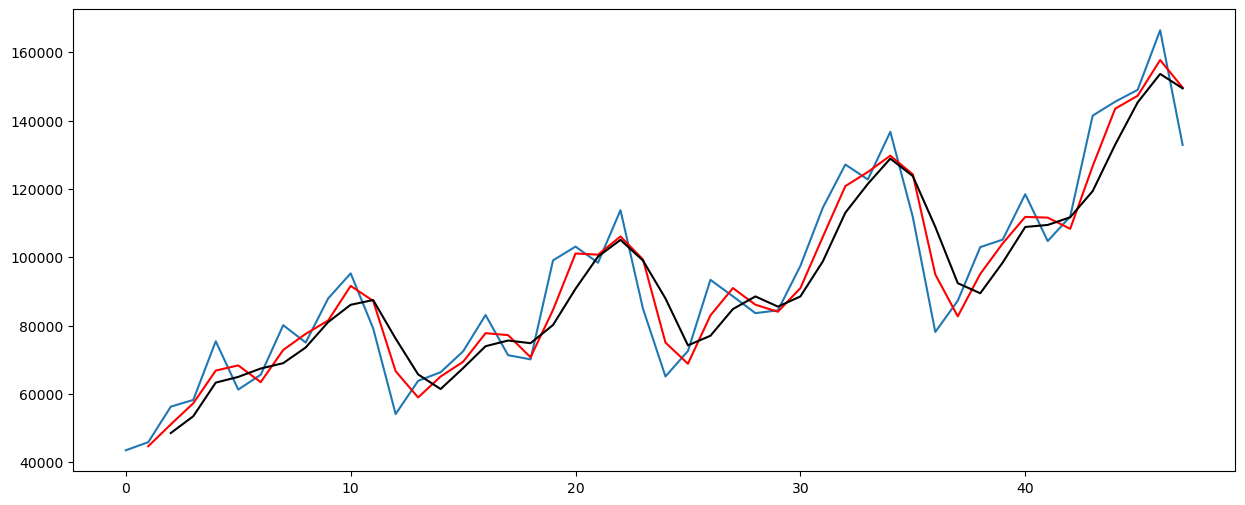

In [43]:
plt.plot('Tempo', 'Faturamento', data = df);
plt.plot('Tempo', 'Media_Movel_2', color='red', data = df);
plt.plot('Tempo', 'Media_Movel_3', color='black', data = df);

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2021-01-01 to 2024-12-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Faturamento    48 non-null     int64  
 1   Media_Movel_2  47 non-null     float64
 2   Tempo          48 non-null     int64  
 3   Media_Movel_3  46 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 1.9 KB


In [47]:
# Excluindo da base variáveis que não vamos usar para a analise

df.drop(['Tempo','Media_Movel_2' ,'Media_Movel_3'],axis=1,inplace=True)
df.head()

,Faturamento
Ano_Mes,
2021-01-01,43484
2021-02-01,45859
2021-03-01,56254
2021-04-01,58224
2021-05-01,75403


#### Algumas Bibliotecas

In [49]:
# time series - statsmodels 

# Seasonality decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# holt winters 
# single exponential smoothing

from statsmodels.tsa.holtwinters import SimpleExpSmoothing   

# double and triple exponential smoothing

# from statsmodels.tsa.holtwinters import ExponentialSmoothing as HWES
from statsmodels.tsa.holtwinters import ExponentialSmoothing 

https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html

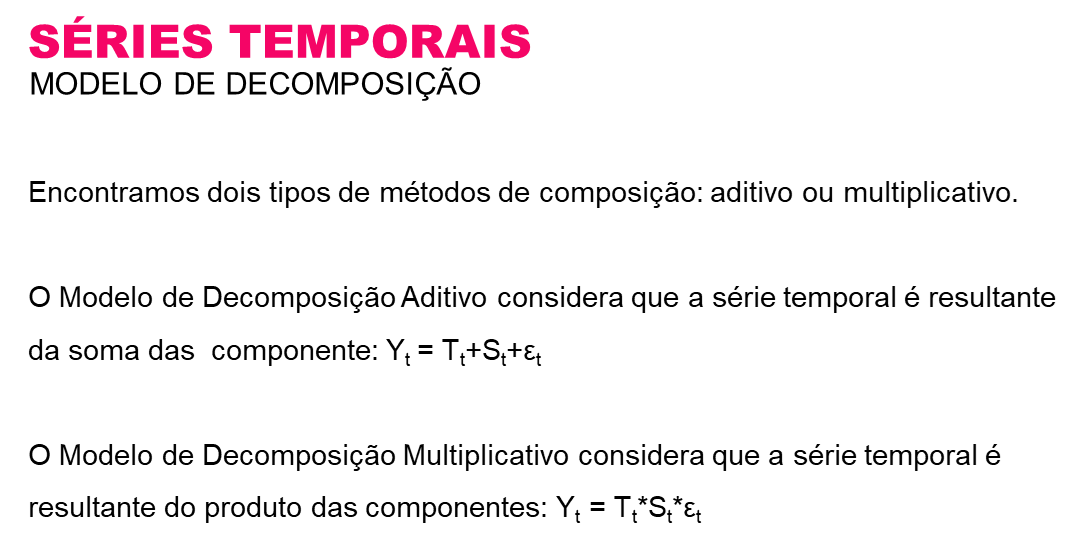!

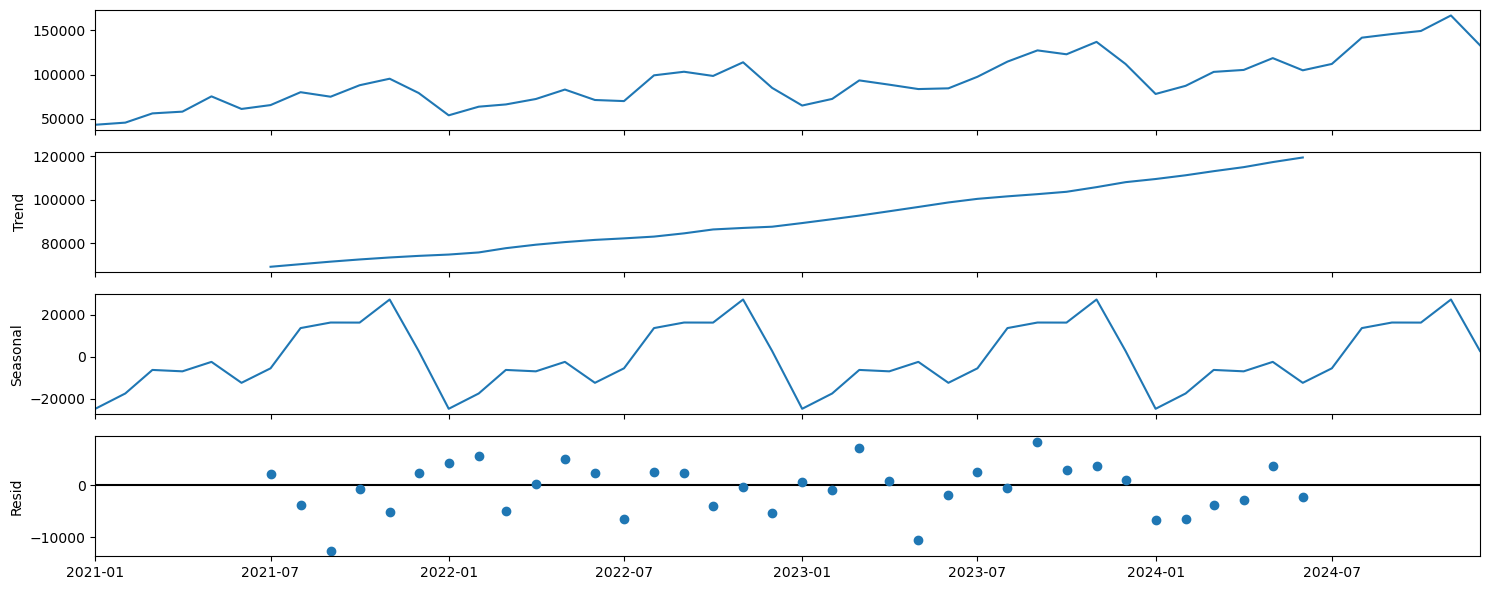

In [51]:
result = seasonal_decompose(df, model='additive')

#print(result.trend)
#print(result.seasonal)
#print(result.resid)
#print(result.observed)

result.plot()
plt.show()

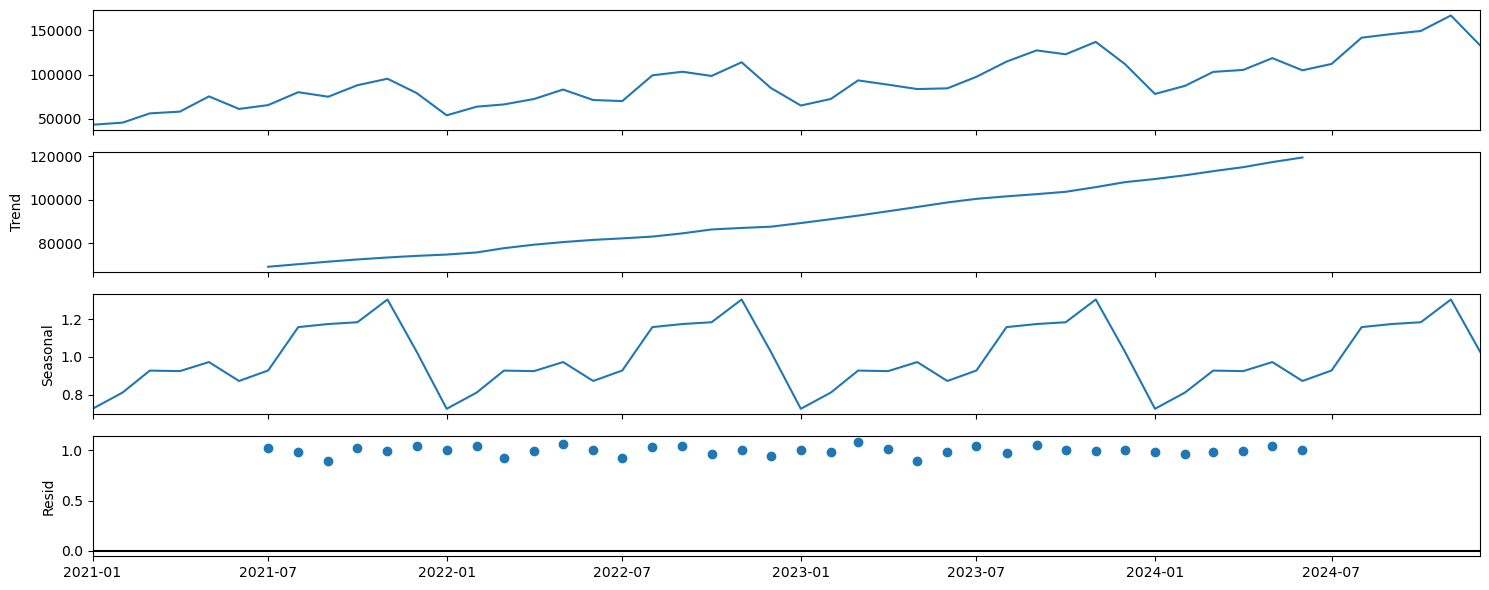

In [53]:
result = seasonal_decompose(df, model='multiplicative')

#print(result.trend)
#print(result.seasonal)
#print(result.resid)
#print(result.observed)

result.plot()
plt.show()

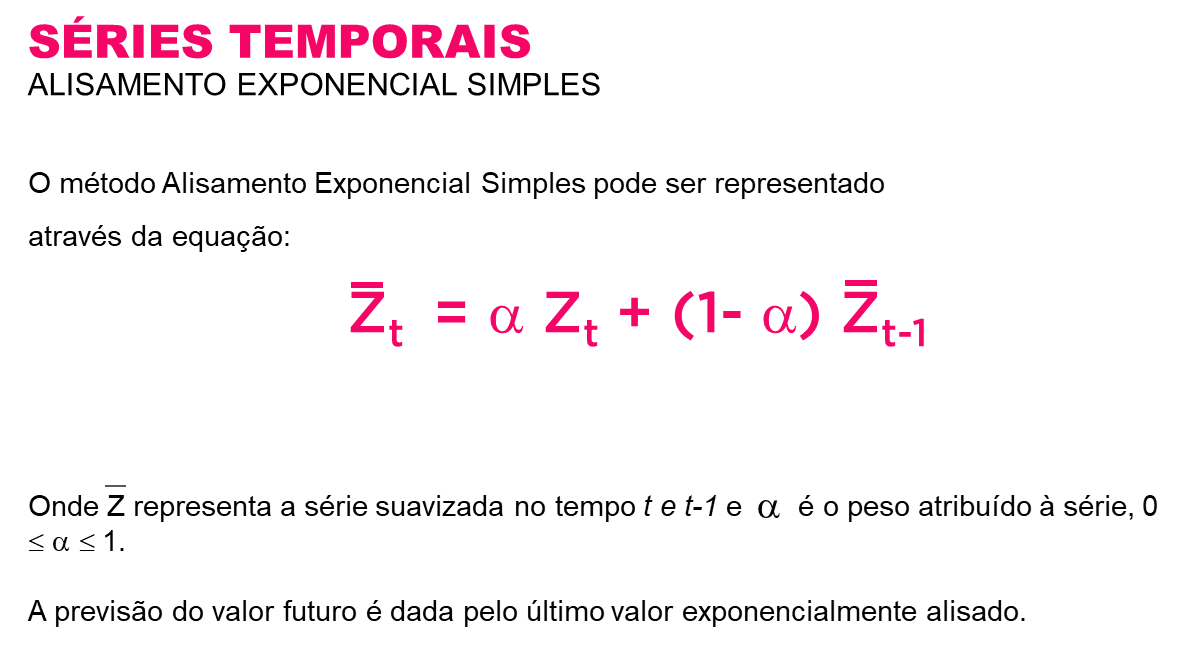!

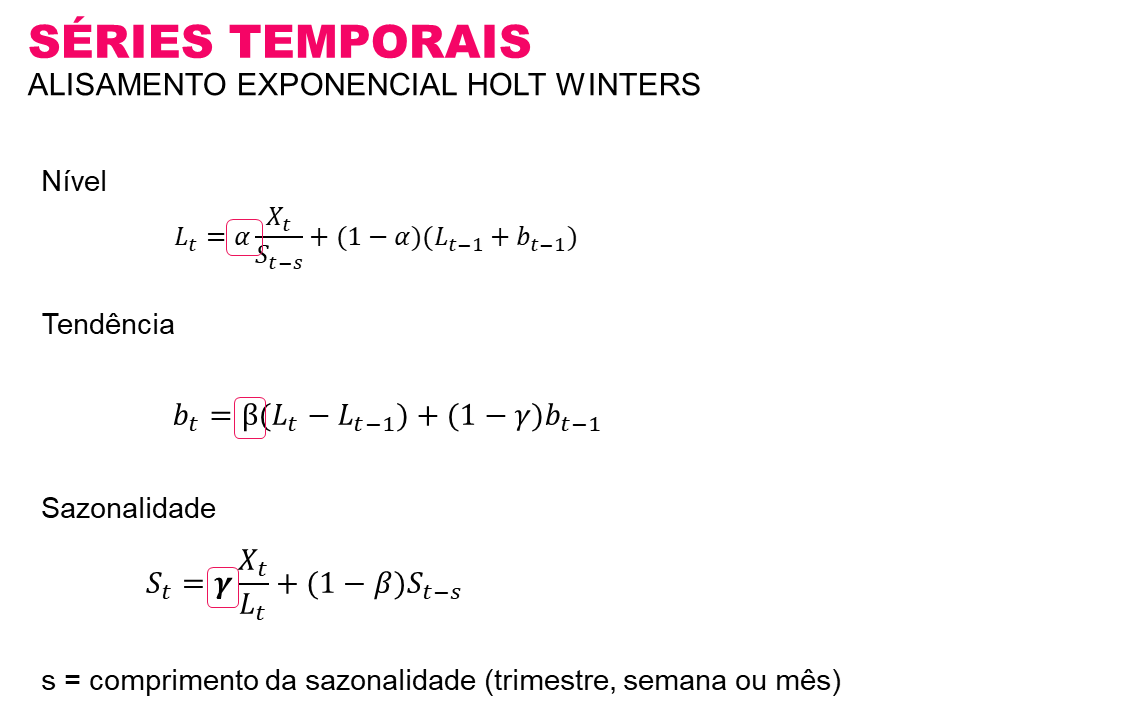!

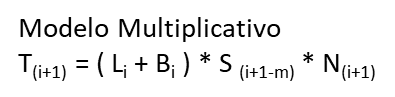
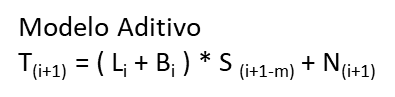
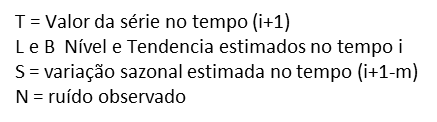

In [55]:
# com seasonal_periods=12 Aditivo

fit1 = ExponentialSmoothing(
    df,
    seasonal_periods=12,
    trend="add",
    seasonal="add",
    initialization_method="estimated",
).fit()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [57]:
fit1

In [59]:
print(fit1.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:              Faturamento   No. Observations:                   48
Model:             ExponentialSmoothing   SSE                     1540848967.047
Optimized:                         True   AIC                            861.651
Trend:                         Additive   BIC                            891.590
Seasonal:                      Additive   AICC                           885.237
Seasonal Periods:                    12   Date:                 Tue, 25 Feb 2025
Box-Cox:                          False   Time:                         20:38:11
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2878571                alpha                 True
smoothing_trend          

In [61]:
# com  seasonal_periods=12  Multiplicativo

fit2 = ExponentialSmoothing(
    df,
    seasonal_periods=12,
    trend="mul",
    seasonal="mul",
    initialization_method="estimated",
).fit()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [63]:
fit2

In [65]:
print(fit2.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:              Faturamento   No. Observations:                   48
Model:             ExponentialSmoothing   SSE                      970667196.793
Optimized:                         True   AIC                            839.470
Trend:                   Multiplicative   BIC                            869.409
Seasonal:                Multiplicative   AICC                           863.056
Seasonal Periods:                    12   Date:                 Tue, 25 Feb 2025
Box-Cox:                          False   Time:                         20:41:27
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1817857                alpha                 True
smoothing_trend          

In [67]:
results = pd.DataFrame(
    index=[r"$\alpha$", r"$\beta$", r"$\phi$", r"$\gamma$", r"$l_0$", "$b_0$", "SSE"]
)
params = [
    "smoothing_level",
    "smoothing_trend",
    "damping_trend",
    "smoothing_seasonal",
    "initial_level",
    "initial_trend",
]
results["Additive"] = [fit1.params[p] for p in params] + [fit1.sse]
results["Multiplicative"] = [fit2.params[p] for p in params] + [fit2.sse]
results

,Additive,Multiplicative
$\alpha$,2.878571e-01,1.817857e-01
$\beta$,9.595238e-02,1.000000e-04
$\phi$,NaN,NaN
$\gamma$,1.000000e-04,1.000000e-04
$l_0$,6.806049e+04,6.806049e+04
$b_0$,1.041937e+03,1.015309e+00
SSE,1.540849e+09,9.706672e+08


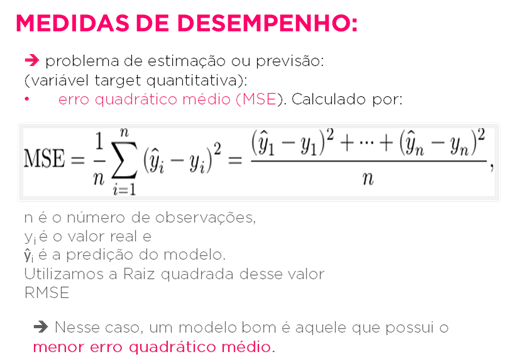!

In [69]:
# Outras medidas de desempenho
# Akaike Information Criterion (AIC)
# Bayesian Information Criterion (BIC

print('Modelo 1 - Aditivo')
print(fit1.aic)
print(fit1.bic)
print(fit1.aicc)

Modelo 1 - Aditivo
861.6511216577501
891.5903378322763
885.2373285543018


In [71]:
print('Modelo 2 - Multiplicativo')
print(fit2.aic)
print(fit2.bic)
print(fit2.aicc)

Modelo 2 - Multiplicativo
839.4700742648704
869.4092904393966
863.0562811614221


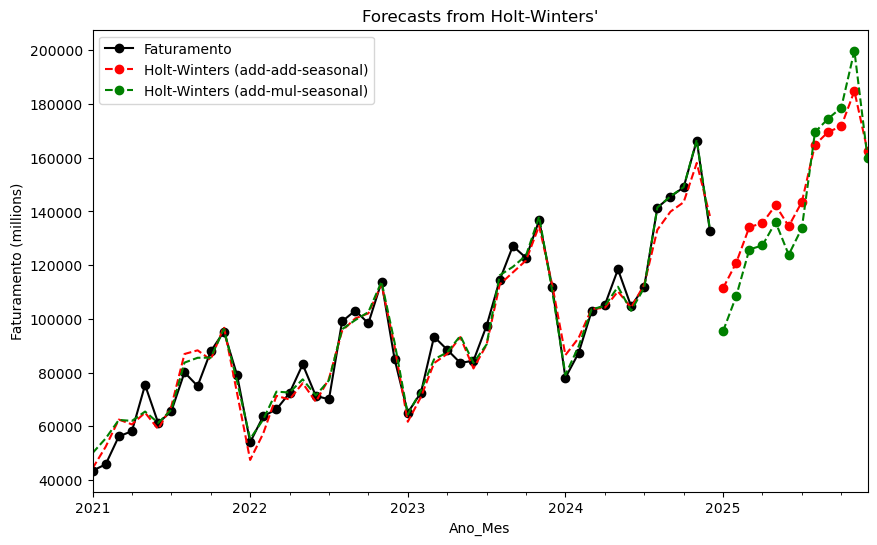

Figure 1: Forecasting Faturamento using Holt-Winters method with both additive and multiplicative seasonality.


In [73]:
ax = df.plot(
    figsize=(10, 6),
    marker="o",
    color="black",
    title="Forecasts from Holt-Winters'",
)
ax.set_ylabel("Faturamento (millions)")
ax.set_xlabel("Year")
fit1.fittedvalues.plot(ax=ax, style="--", color="red")
fit2.fittedvalues.plot(ax=ax, style="--", color="green")

fit1.forecast(12).rename("Holt-Winters (add-add-seasonal)").plot(
    ax=ax, style="--", marker="o", color="red", legend=True
)
fit2.forecast(12).rename("Holt-Winters (add-mul-seasonal)").plot(
    ax=ax, style="--", marker="o", color="green", legend=True
)

plt.show()
print(
    "Figure 1: Forecasting Faturamento using Holt-Winters method with both additive and multiplicative seasonality."
)



#### Selecionando o modelo com menor RMSE

In [75]:
# Selecionando o modelo com menor RMSE   - fit_sel

fit_sel = ExponentialSmoothing(
    df,
    seasonal_periods=12,
    trend="mul",
    seasonal="mul",
    initialization_method="estimated",
).fit()




/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [77]:
print(fit_sel.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:              Faturamento   No. Observations:                   48
Model:             ExponentialSmoothing   SSE                      970667196.793
Optimized:                         True   AIC                            839.470
Trend:                   Multiplicative   BIC                            869.409
Seasonal:                Multiplicative   AICC                           863.056
Seasonal Periods:                    12   Date:                 Tue, 25 Feb 2025
Box-Cox:                          False   Time:                         20:49:17
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1817857                alpha                 True
smoothing_trend          

In [79]:
results = pd.DataFrame(
    index=[r"$\alpha$", r"$\beta$", r"$\phi$", r"$\gamma$", r"$l_0$", "$b_0$", "SSE"]
    )
params = [
    "smoothing_level",
    "smoothing_trend",
    "damping_trend",
    "smoothing_seasonal",
    "initial_level",
    "initial_trend",
]
#results["Additive"] = [fit1.params[p] for p in params] + [fit1.sse]
results["Multiplicative"] = [fit_sel.params[p] for p in params] + [fit_sel.sse]
results

,Multiplicative
$\alpha$,1.817857e-01
$\beta$,1.000000e-04
$\phi$,NaN
$\gamma$,1.000000e-04
$l_0$,6.806049e+04
$b_0$,1.015309e+00
SSE,9.706672e+08


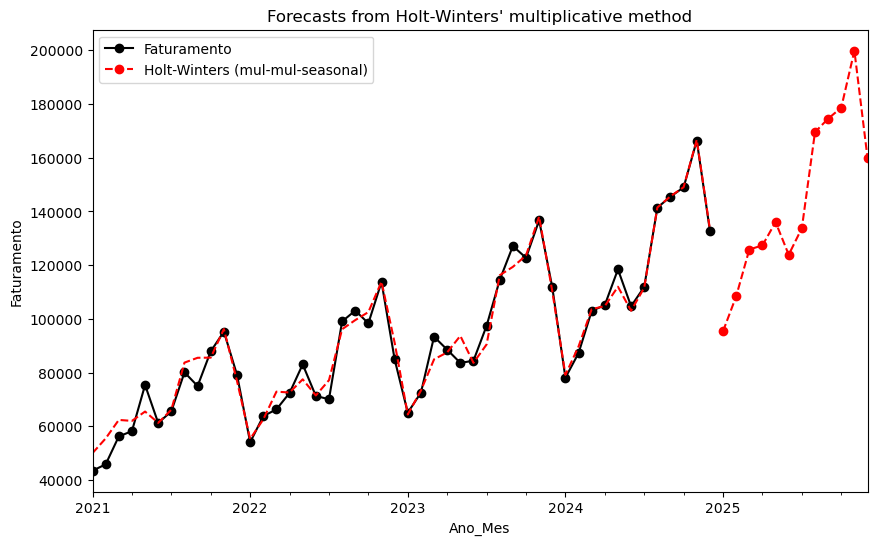

Figure 2: Forecasting Faturamento using Holt-Winters method with multiplicative seasonality.


In [81]:
#função fittedvalues estima a serie no mesma periodo de desenvolvimento
#função forecast estima a serie em um certo periodo futuro

ax = df.plot(
    figsize=(10, 6),
    marker="o",
    color="black",
    title="Forecasts from Holt-Winters' multiplicative method",
)
ax.set_ylabel("Faturamento")
ax.set_xlabel("Mês/Ano")
fit_sel.fittedvalues.plot(ax=ax, style="--", color="red")
fit_sel.forecast(12).rename("Holt-Winters (mul-mul-seasonal)").plot(
    ax=ax, style="--", marker="o", color="red", legend=True
)


plt.show()
print(
    "Figure 2: Forecasting Faturamento using Holt-Winters method with multiplicative seasonality."
)



<Axes: title={'center': "Forecasts and simulations from Holt-Winters' multiplicative method"}, xlabel='Ano_Mes', ylabel='Faturamento'>

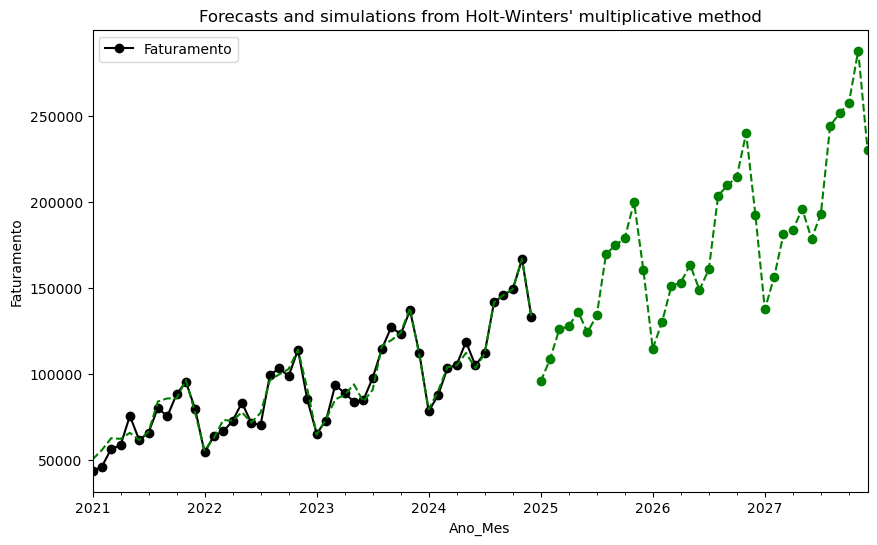

In [83]:
# forecast 3 anos - 36 meses
results = pd.DataFrame(
    index=[r"$\alpha$", r"$\beta$", r"$\phi$", r"$\gamma$", r"$l_0$", "$b_0$", "SSE"]
)
params = [
    "smoothing_level",
    "smoothing_trend",
    "damping_trend",
    "smoothing_seasonal",
    "initial_level",
    "initial_trend",
]
results["Multiplicative"] = [fit_sel.params[p] for p in params] + [fit_sel.sse]
ax = df.plot(
    figsize=(10, 6),
    marker="o",
    color="black",
    title="Forecasts and simulations from Holt-Winters' multiplicative method",
)
ax.set_ylabel("Faturamento")
ax.set_xlabel("Mês/Ano")
fit_sel.fittedvalues.plot(ax=ax, style="--", color="green")
fit_sel.forecast(36).rename("Holt-Winters (mul-mul-seasonal)").plot(
    ax=ax, style="--", marker="o", color="green")


<Axes: title={'center': "Forecasts and simulations from Holt-Winters' multiplicative method"}, xlabel='Ano_Mes', ylabel='Faturamento'>

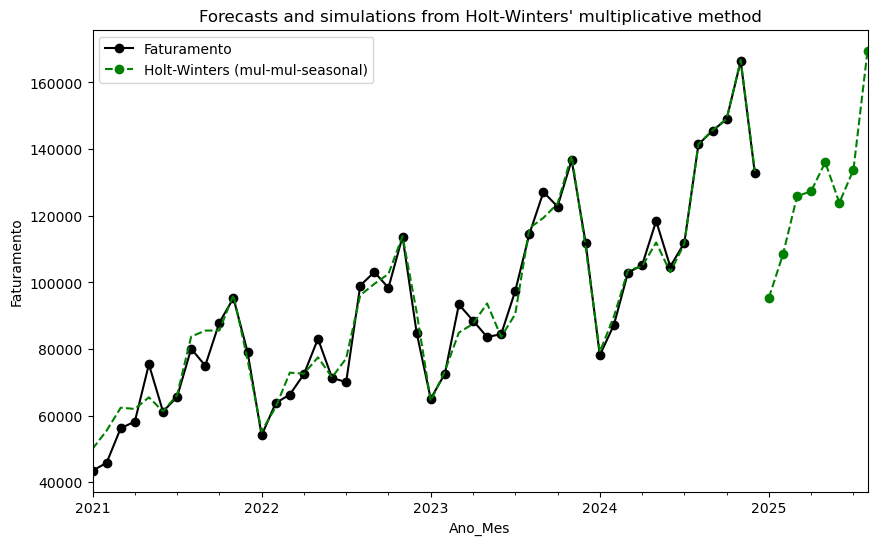

In [85]:
# forecast  8 meses
results = pd.DataFrame(
    index=[r"$\alpha$", r"$\beta$", r"$\phi$", r"$\gamma$", r"$l_0$", "$b_0$", "SSE"]
)
params = [
    "smoothing_level",
    "smoothing_trend",
    "damping_trend",
    "smoothing_seasonal",
    "initial_level",
    "initial_trend",
]
results["Multiplicative"] = [fit_sel.params[p] for p in params] + [fit_sel.sse]
ax = df.plot(
    figsize=(10, 6),
    marker="o",
    color="black",
    title="Forecasts and simulations from Holt-Winters' multiplicative method",
)
ax.set_ylabel("Faturamento")
ax.set_xlabel("Mês/Ano")
fit_sel.fittedvalues.plot(ax=ax, style="--", color="green")
fit_sel.forecast(8).rename("Holt-Winters (mul-mul-seasonal)").plot(
    ax=ax, style="--", marker="o", color="green", legend=True
)


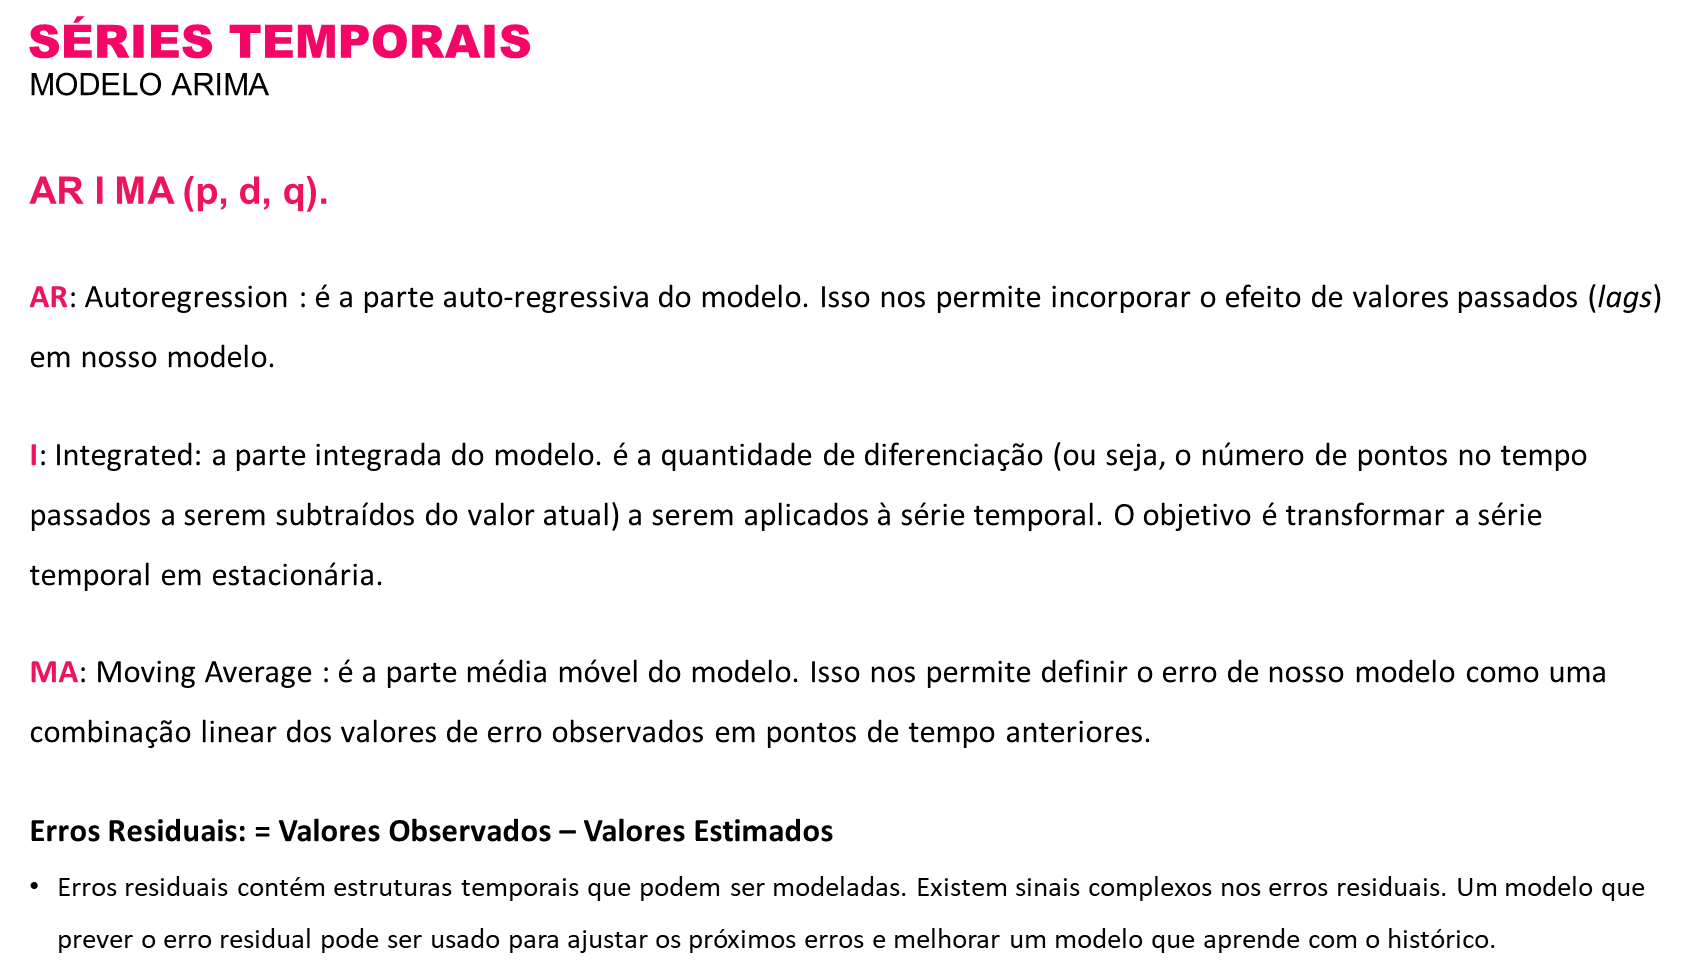!


https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html

In [89]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00


In [90]:

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.tsa.arima_process import arma_generate_sample
import statsmodels.api as sm
 
from pmdarima.arima import auto_arima


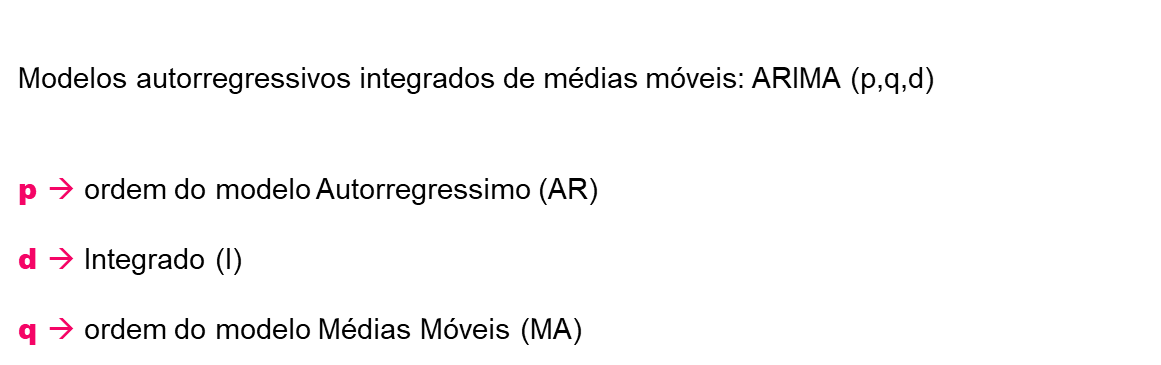!

Modelos ARIMA são capazes também de modelar séries que apresentam um componente sazonal, sendo descrito como:
ARIMA   (p,d,q)(P,D,Q)m 

Onde o primeiro parênteses se refere à parte não-sazonal do modelo e o segundo à parte sazonal.  
m   corresponde ao número de períodos sazonais.

Ajustar um modelo SARIMA é semelhante ao processo de ajustar um ARIMA:

Quantidade de termos em p

Ambos os gráficos terão o primeiro pirulito com valor 1. Para saber o quanto de termos AR irá precisar, olhe para o gráfico de ACF e veja se o segundo lollipop caiu exponencialmente. Se caiu, olhe para o gŕafico de PACF e conte quantos pirulitos passam o valor crítico (faixa azulada horizontal) antes de retornarem para dentro da faixa. No caso da nossa imagem acima, nosso p teria 1 termo.

Quantidade de termos em q

Um processo muito semelhante é feito para saber a quantidade de termos q. Olhe para o gráfico de PACF e veja se o segundo lollipop caiu exponencialmente. Se caiu, olhe para o gŕafico de ACF e conte quantos pirulitos passam o valor crítico (faixa azulada horizontal) antes de retornarem para dentro da faixa. No caso da nossa imagem acima, nosso q teria 1 termo.

Auto Correlation Function (ACF)

A correlação entre as observações no ponto atual no tempo e as observações em todos os pontos anteriores no tempo. 
Ambos os gráficos terão o primeira "barra" com valor 1.


Podemos usar ACF para determinar o número ideal de terARoA. O número de termos determina a ordem dodelo
Para saber o quanto de termos AR irá precisar, olhe para o gráfico de ACF e veja se a segunda "barra" se caiu exponencialmente. Se caiu, olhe para o gŕafico de PACF e conte quantas "barras" passam o valor crítico (faixa azulada horizontal) antes de retornarem para dentro da faixa.  lo.
Partial Auto Correlation Functio (P

ACF)
O PACF expressa a correlação entre as observações feitas em dois pontos no tempo enquanto contabiliza qualquer influência de outros pontos da


dos. Podemos usar o PACF para determinar o número ideal de termos a serem usados ​​no o del
 AR. O número de termos detersuaina a .

O processo para definir a quantidade de termos q.
Olhe para o gráfico de PACF e veja se a segunda "barrinha" caiu exponencialmente. Se caiu, olhe para o gŕafico de ACF e conte quantas "barrinha" passam o valor crítico (faixa azulada horizontal) antes de retornarem para dentro da faixa. 

O Plot colocaplotar os LAGS na horizontal e as correlações no eixo vertical usando as funções plot_acf e plot_pacf.

In [93]:
#import pandas.util.testing as tm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from matplotlib import pyplot

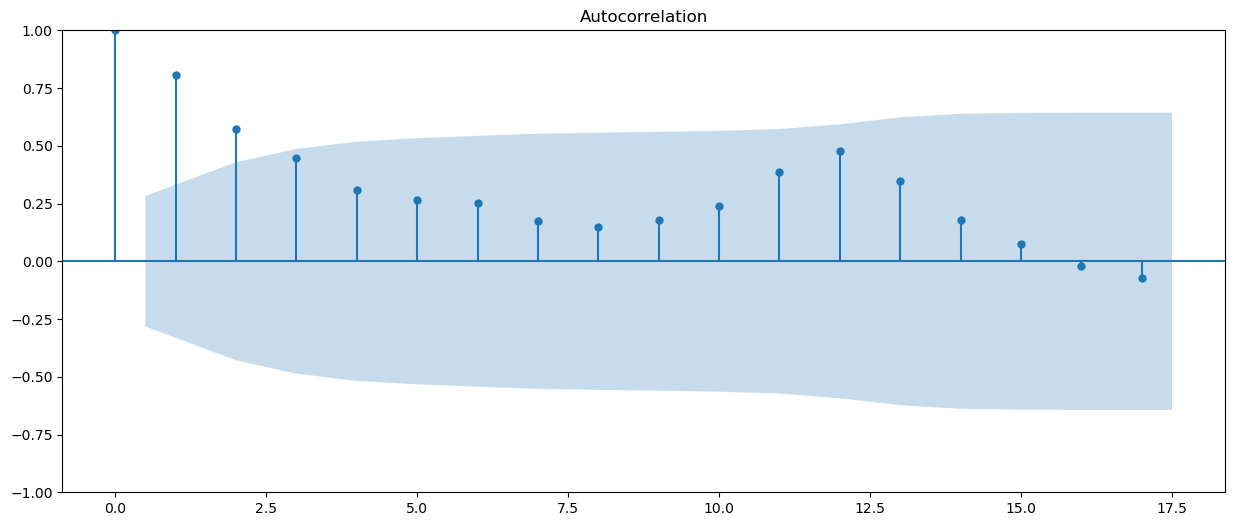

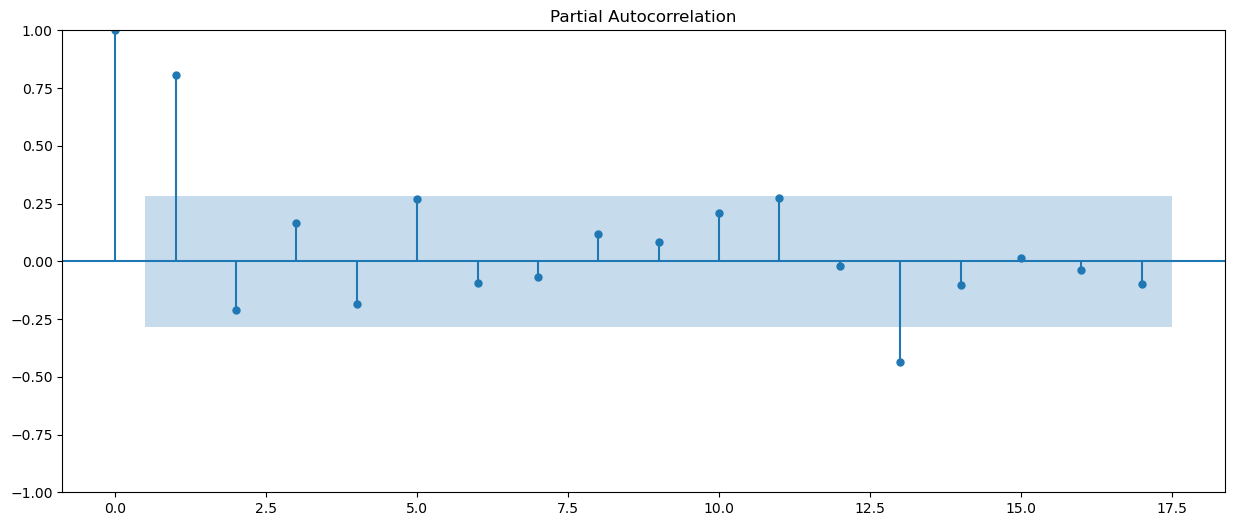

In [95]:

plot_acf(df)
plot_pacf(df)
plt.show()

In [97]:
# For non-seasonal data
#p=1 (AR specification), d=1 (Integration order), q=0 or 1 (MA specification/polynomial)


model_auto = auto_arima(df.Faturamento, start_p=1, start_q=1,
                      test='adf',
                      max_p=12, max_q=12,
                      m=12,             
                      d=2,          
                      seasonal=True,   
                      start_P=0, 
                      D=None, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,2,1)(0,1,1)[12]             : AIC=731.737, Time=0.11 sec
 ARIMA(0,2,0)(0,1,0)[12]             : AIC=760.889, Time=0.01 sec
 ARIMA(1,2,0)(1,1,0)[12]             : AIC=749.419, Time=0.06 sec
 ARIMA(0,2,1)(0,1,1)[12]             : AIC=inf, Time=0.18 sec
 ARIMA(1,2,1)(0,1,0)[12]             : AIC=730.592, Time=0.03 sec
 ARIMA(1,2,1)(1,1,0)[12]             : AIC=731.638, Time=0.09 sec
 ARIMA(1,2,1)(1,1,1)[12]             : AIC=733.597, Time=0.08 sec
 ARIMA(0,2,1)(0,1,0)[12]             : AIC=inf, Time=0.03 sec
 ARIMA(1,2,0)(0,1,0)[12]             : AIC=751.116, Time=0.01 sec
 ARIMA(2,2,1)(0,1,0)[12]             : AIC=731.349, Time=0.03 sec
 ARIMA(1,2,2)(0,1,0)[12]             : AIC=inf, Time=0.09 sec
 ARIMA(0,2,2)(0,1,0)[12]             : AIC=728.474, Time=0.03 sec
 ARIMA(0,2,2)(1,1,0)[12]             : AIC=inf, Time=0.21 sec
 ARIMA(0,2,2)(0,1,1)[12]             : AIC=inf, Time=0.23 sec
 ARIMA(0,2,2)(1,1,1)[12]             : AIC=730.892, T

In [99]:
model_auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   48
Model:             SARIMAX(0, 2, 2)x(0, 1, [], 12)   Log Likelihood                -361.237
Date:                             Tue, 25 Feb 2025   AIC                            728.474
Time:                                     21:30:43   BIC                            733.053
Sample:                                 01-01-2021   HQIC                           730.036
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.2901      0.414     -3.116      0.002      -2.102      -0.479
ma.L2          0.2990      0.233      1.285      0.199      -0.157       0.755
sigma2      1.187e+08   1.98e-09   5.99e+16      0.000    1.19e+08    1.19e+08
===================================================================================
Ljung-Box (L1) (Q):                   1.69   Jarque-Bera (JB):                 1.12
Prob(Q):                              0.19   Prob(JB):                         0.57
Heteroskedasticity (H):               0.97   Skew:                             0.27
Prob(H) (two-sided):                  0.96   Kurtosis:                         2.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.29e+32. Standard errors may be unstable.
"""

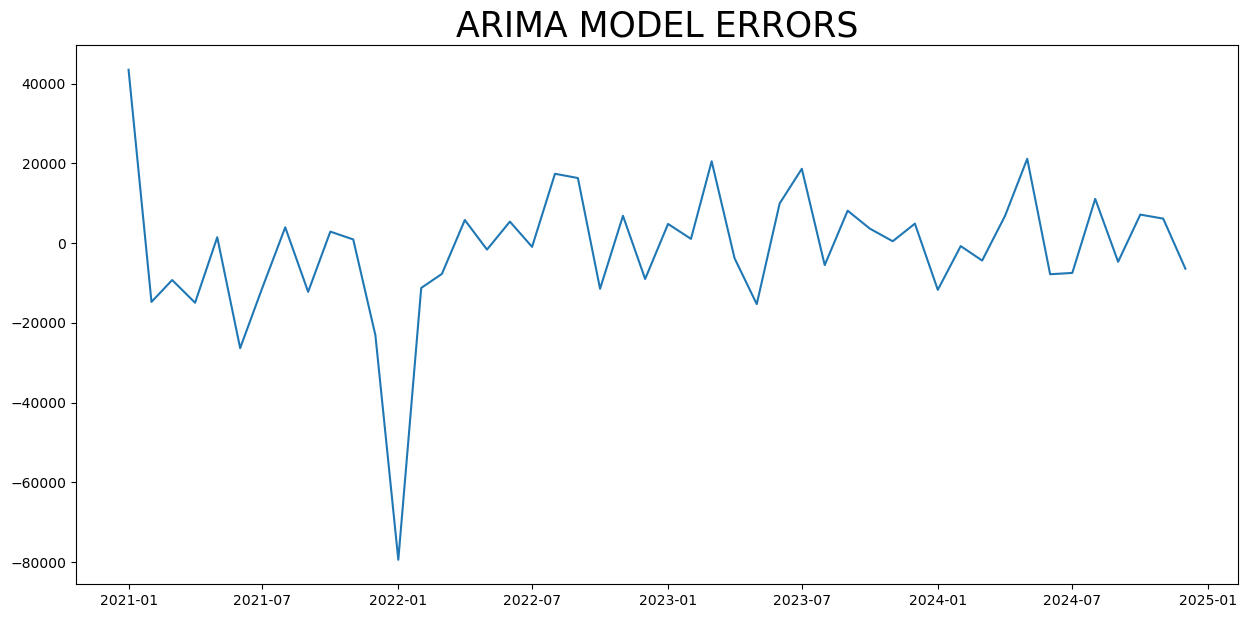

In [101]:
plt.figure(figsize=(15,7))
plt.plot(model_auto.resid())
plt.title("ARIMA MODEL ERRORS", size=25)
plt.show()

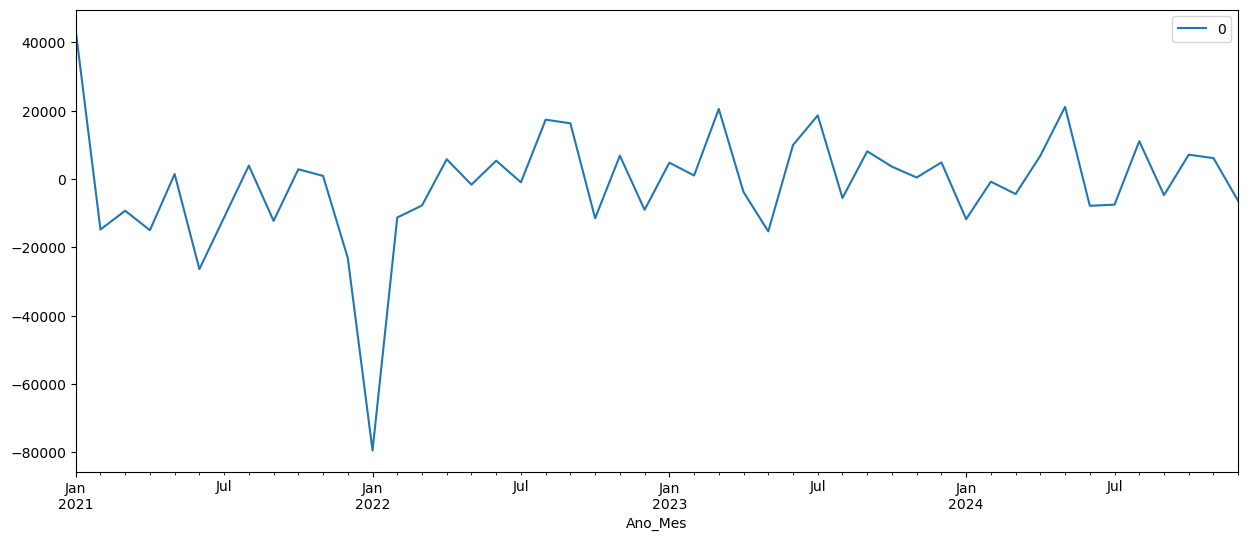

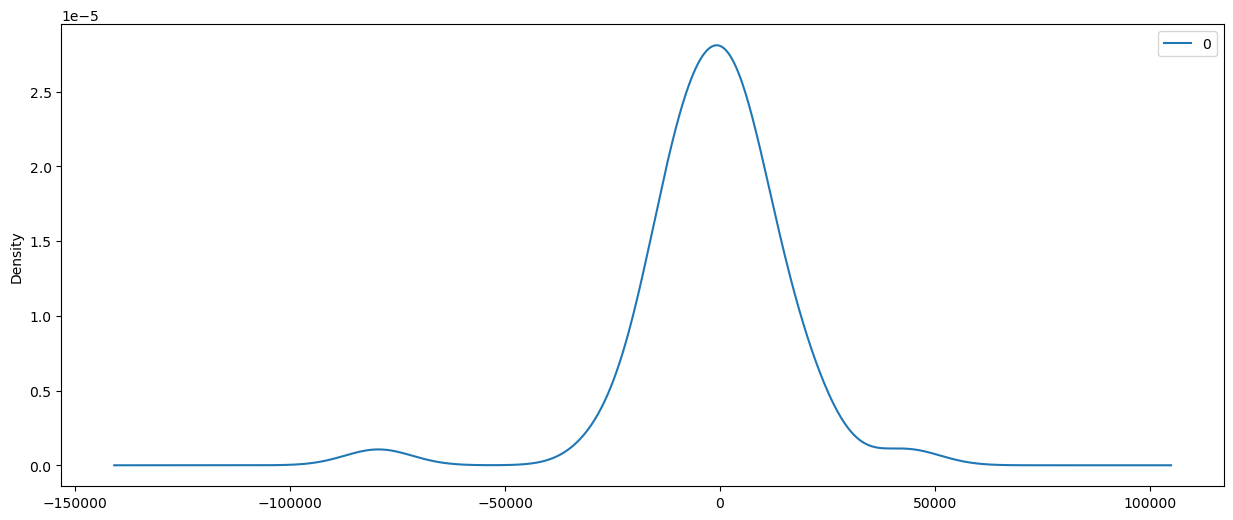

                  0
count     48.000000
mean   -1502.684303
std    16978.769106
min   -79439.979029
25%    -9062.705234
50%     -141.040416
75%     6320.136535
max    43484.000000


In [103]:
 from matplotlib import pyplot
residuals = pd.DataFrame(model_auto.resid())
residuals.plot()
pyplot.show()
# density plot of residuals
residuals.plot(kind='kde')
pyplot.show()
# summary stats of residuals
print(residuals.describe())

In [107]:
#teste de normalidade
import scipy

scipy.stats.shapiro(model_auto.resid())


ShapiroResult(statistic=0.8434432628405208, pvalue=1.4629927039309426e-05)

In [113]:

model_2=ARIMA(df['Faturamento'],order=(0, 2, 2),seasonal_order=(0,0,1,12))

results=model_2.fit()


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving ave

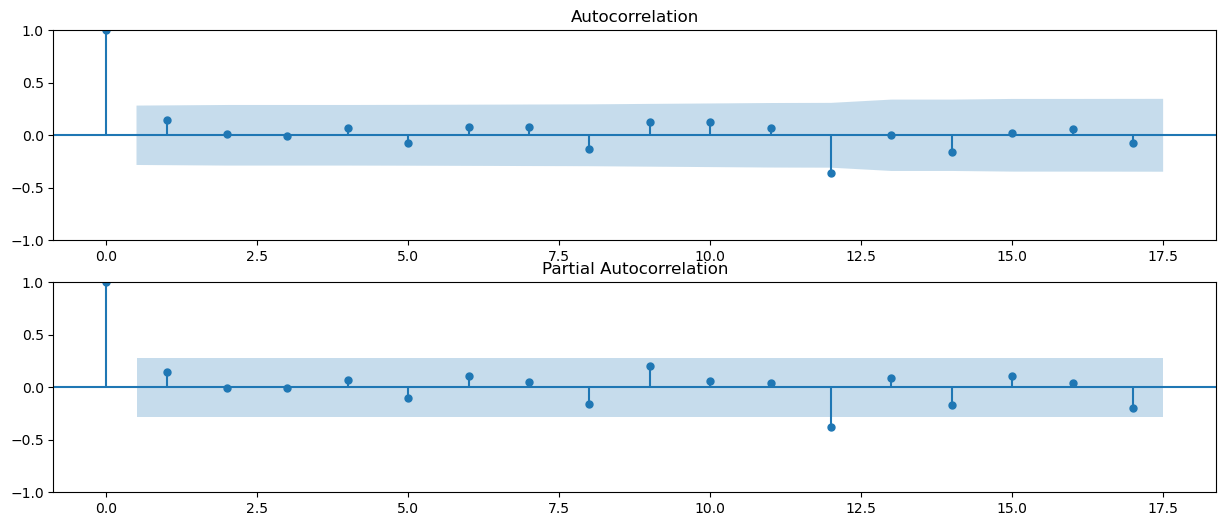

In [115]:

# plots de autocorrelação
pyplot.figure() 
pyplot.subplot(211)
plot_acf(residuals, ax=pyplot.gca())
pyplot.subplot(212)
plot_pacf(residuals, ax=pyplot.gca())
pyplot.show()

In [119]:
model_fit_2=model_2.fit()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [121]:
model_fit_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                        Faturamento   No. Observations:                   48
Model:             ARIMA(0, 2, 2)x(0, 0, [1], 12)   Log Likelihood                -509.027
Date:                            Tue, 25 Feb 2025   AIC                           1026.054
Time:                                    21:41:05   BIC                           1033.369
Sample:                                01-01-2021   HQIC                          1028.794
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9326      0.365     -2.556      0.011      -1.648      -0.217
ma.L2         -0.0340      0.331     -0.103      0.918      -0.683       0.615
ma.S.L12       0.3455      0.318      1.088      0.277      -0.277       0.968
sigma2      3.252e+08   6.76e-10   4.81e+17      0.000    3.25e+08    3.25e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):                 3.44
Prob(Q):                              0.71   Prob(JB):                         0.18
Heteroskedasticity (H):               1.21   Skew:                            -0.66
Prob(H) (two-sided):                  0.72   Kurtosis:                         3.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.19e+33. Standard errors may be unstable.
"""

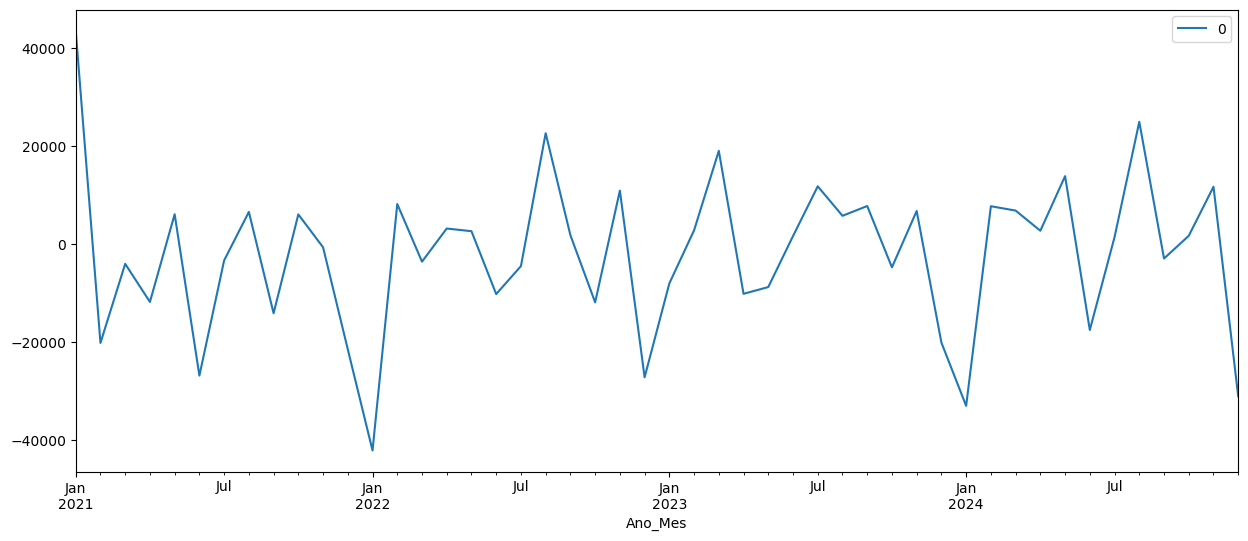

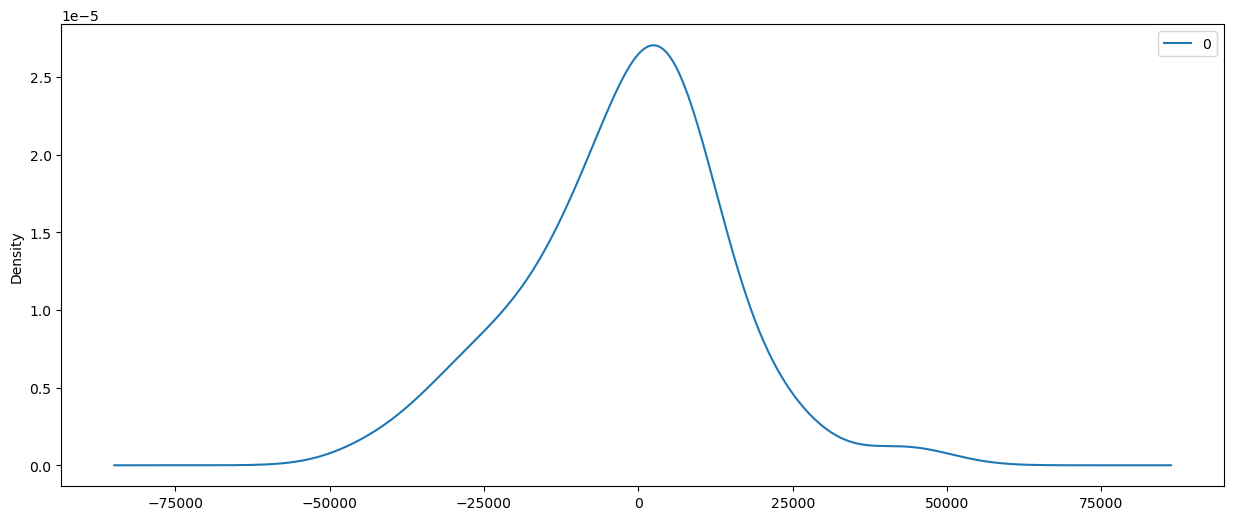

                  0
count     48.000000
mean   -2110.961585
std    15976.551831
min   -42085.825646
25%   -10611.925165
50%     1501.160212
75%     6740.983398
max    43484.000000


In [123]:
 from matplotlib import pyplot
residuals = pd.DataFrame(model_fit_2.resid)
residuals.plot()
pyplot.show()
# density plot of residuals
residuals.plot(kind='kde')
pyplot.show()
# summary stats of residuals
print(residuals.describe())

In [125]:
print(model_fit_2.sse)

12210655418.14389


In [127]:
#teste de normalidade
import scipy

scipy.stats.shapiro(model_fit_2.resid)



ShapiroResult(statistic=0.9734333259943952, pvalue=0.3425594479371312)

<Axes: xlabel='Ano_Mes'>

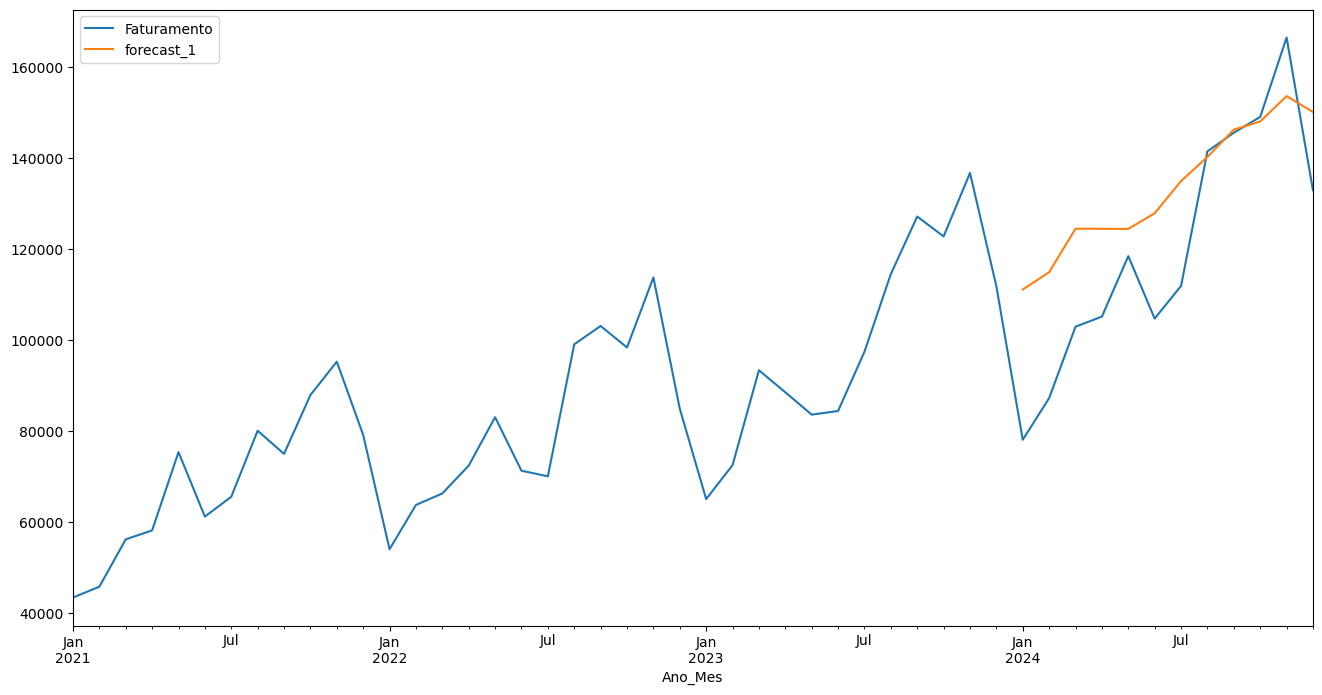

In [129]:
df['forecast_1']=model_fit_2.predict(start=36,end=48,dynamic=True)
df[['Faturamento','forecast_1']].plot(figsize=(16,8))


In [131]:

print(model_fit_2.predict(start=48,end=60))


2025-01-01    122796.989272
2025-02-01    127250.667535
2025-03-01    131970.820800
2025-04-01    135347.796215
2025-05-01    142552.351089
2025-06-01    139233.006430
2025-07-01    141866.695720
2025-08-01    152851.459424
2025-09-01    154797.405017
2025-10-01    157978.107027
2025-11-01    164685.157721
2025-12-01    156904.515433
2026-01-01    158967.760196
Freq: MS, Name: predicted_mean, dtype: float64


<Axes: title={'center': 'Forecasts ARIMA'}, xlabel='Ano_Mes', ylabel='Faturamento'>

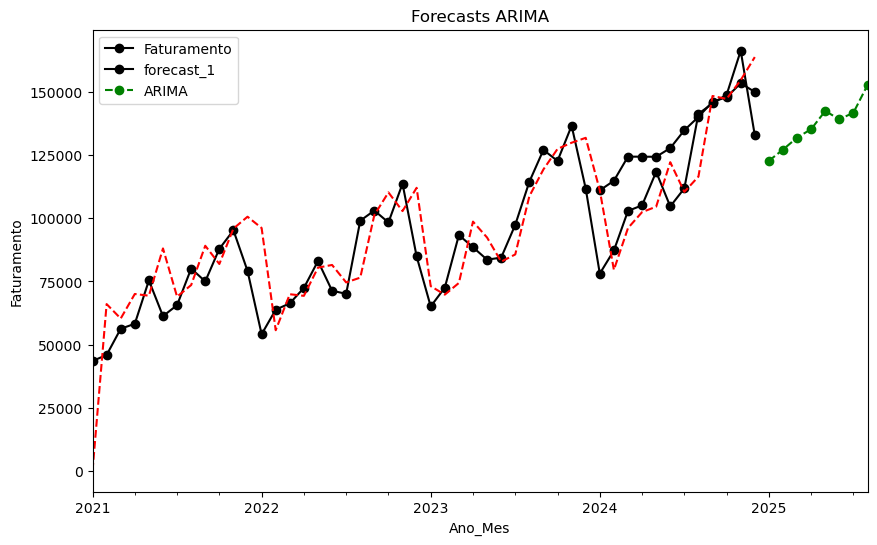

In [133]:
# forecast  8 meses

ax = df.plot(
    figsize=(10, 6),
    marker="o",
    color="black",
    title="Forecasts ARIMA",
)
ax.set_ylabel("Faturamento")
ax.set_xlabel("Mês/Ano")
model_fit_2.fittedvalues.plot(ax=ax, style="--", color="red")
model_fit_2.forecast(8).rename("ARIMA").plot(
    ax=ax, style="--", marker="o", color="green", legend=True
)


### Como dividir em amostra train e amostra teste

In [135]:
# Excluindo da base variáveis que não vamos usar para a analise


df.head()

,Faturamento,forecast_1
Ano_Mes,,
2021-01-01,43484,NaN
2021-02-01,45859,NaN
2021-03-01,56254,NaN
2021-04-01,58224,NaN
2021-05-01,75403,NaN


In [137]:
df.drop(['forecast_1'],axis=1,inplace=True)
df.head()

,Faturamento
Ano_Mes,
2021-01-01,43484
2021-02-01,45859
2021-03-01,56254
2021-04-01,58224
2021-05-01,75403


In [139]:
train = df.loc['2021-01-01':'2023-12-01']

In [141]:
train

,Faturamento
Ano_Mes,
2021-01-01,43484
2021-02-01,45859
2021-03-01,56254
2021-04-01,58224
2021-05-01,75403
2021-06-01,61255
2021-07-01,65601
2021-08-01,80099
2021-09-01,75017


In [143]:
test = df.loc['2024-01-01':]

In [145]:
test

,Faturamento
Ano_Mes,
2024-01-01,78111
2024-02-01,87265
2024-03-01,102945
2024-04-01,105157
2024-05-01,118438
2024-06-01,104727
2024-07-01,111890
2024-08-01,141438
2024-09-01,145518


In [147]:
model_train=ARIMA(train['Faturamento'],order=(0, 2, 2),seasonal_order=(0,0,1,12))

model_train


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [149]:
result_train=model_train.fit()
result_train

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [151]:
result_train.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                        Faturamento   No. Observations:                   36
Model:             ARIMA(0, 2, 2)x(0, 0, [1], 12)   Log Likelihood                -373.377
Date:                            Tue, 25 Feb 2025   AIC                            754.753
Time:                                    21:41:38   BIC                            760.859
Sample:                                01-01-2021   HQIC                           756.835
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9200      0.352     -2.612      0.009      -1.610      -0.230
ma.L2         -0.0326      0.348     -0.094      0.925      -0.714       0.649
ma.S.L12       0.3890      0.324      1.202      0.229      -0.245       1.023
sigma2      2.457e+08   1.35e-09   1.82e+17      0.000    2.46e+08    2.46e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):                 4.54
Prob(Q):                              0.65   Prob(JB):                         0.10
Heteroskedasticity (H):               0.39   Skew:                            -0.75
Prob(H) (two-sided):                  0.13   Kurtosis:                         3.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.08e+33. Standard errors may be unstable.
"""

In [153]:
forecast_arima=result_train.predict(n_periods=48)

In [155]:
forecast_arima

2021-01-01         0.000000
2021-02-01     66016.491186
2021-03-01     60322.744747
2021-04-01     70030.827998
2021-05-01     69336.585717
2021-06-01     88067.033378
2021-07-01     68922.728553
2021-08-01     73509.380330
2021-09-01     89095.049485
2021-10-01     81846.121924
2021-11-01     95884.107309
2021-12-01    100346.745714
2022-01-01     97058.566280
2022-02-01     55077.310095
2022-03-01     69651.962436
2022-04-01     68760.470208
2022-05-01     80431.777486
2022-06-01     80581.705490
2022-07-01     74213.969991
2022-08-01     76373.287713
2022-09-01    100761.441625
2022-10-01    110328.226657
2022-11-01    102657.670220
2022-12-01    111244.357539
2023-01-01     70757.185852
2023-02-01     69827.876603
2023-03-01     73915.384596
2023-04-01     98776.480795
2023-05-01     92212.429967
2023-06-01     82399.755277
2023-07-01     85289.743037
2023-08-01    109459.510509
2023-09-01    119548.811172
2023-10-01    126986.055827
2023-11-01    130389.290026
2023-12-01    131069

In [157]:
result_train

<Axes: >

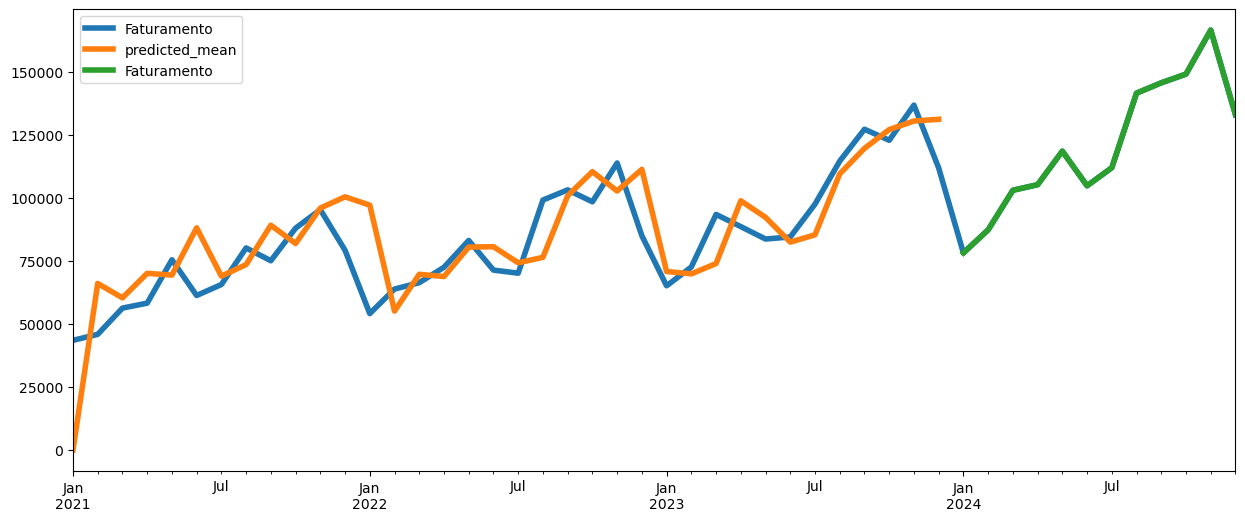

In [159]:
pd.concat([df,forecast_arima,test], axis=1).plot(linewidth=4)

<Axes: title={'center': 'ARIMA TREINO'}, xlabel='Ano_Mes', ylabel='Faturamento'>

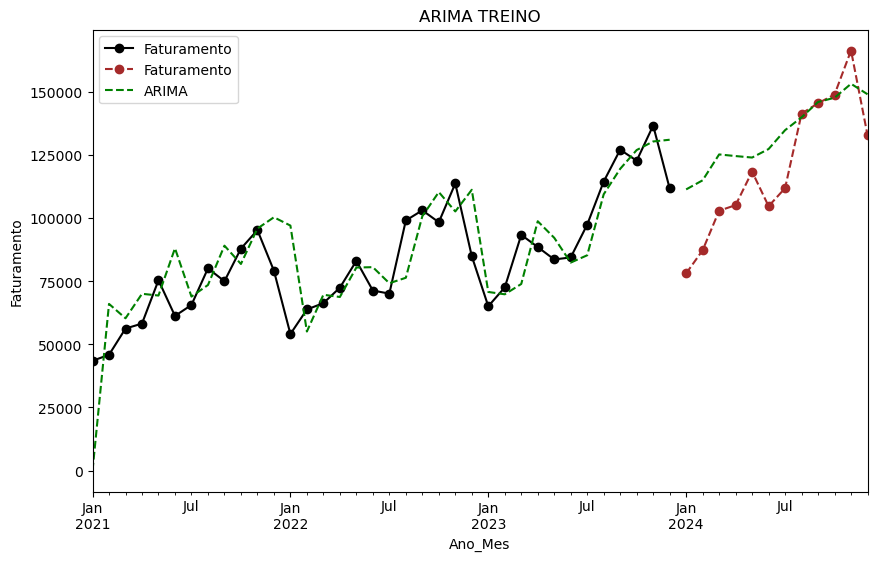

In [161]:
ax = train.plot(
    figsize=(10, 6),
    marker="o",
    color="black",
    title="ARIMA TREINO",
)
ax.set_ylabel("Faturamento")
ax.set_xlabel("Mês/Ano")
result_train.fittedvalues.plot(ax=ax, style="--", color="green")
test.plot(ax=ax, style="--",marker="o", color="brown")
result_train.forecast(12).rename("ARIMA").plot(
    ax=ax, style="--",  color="green", legend=True
)


## PROJEÇÃO UTILIZANDO FB PROPHET


O Prophet é uma biblioteca desenvolvida pelo facebook.

Uma biblioteca mais utilizada para projeções de série temporal devido a a sua simplicidade,

aliado com o plotly, com muitas possibilidades de visualizações de dados,

alguns afirmam que transformou em uma das melhores ferramenta para projeções de dados de série temporal.

In [163]:
https://pypi.org/project/prophet/

SyntaxError: invalid syntax (1992343727.py, line 1)


Profeta é um procedimento para previsão de dados de séries temporais com base em um modelo aditivo onde tendências não lineares são ajustadas à sazonalidade anual, semanal e diária, além dos efeitos dos feriados.

Funciona melhor com séries temporais que apresentam fortes efeitos sazonais e várias temporadas de dados históricos. 

O Prophet é robusto em relação à falta de dados e às mudanças na tendência e normalmente lida bem com valores discrepantes.

fonte:https://pypi.org/project/prophet/

In [165]:
pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 29.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.7/820.7 kB 41.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [166]:
from prophet import Prophet

In [169]:
X=pd.DataFrame(index=range(0,len(train)))
X['ds'] = train.index             
X['y'] =train['Faturamento'].values
X.tail()

,ds,y
31,2023-08-01,114500
32,2023-09-01,127127
33,2023-10-01,122751
34,2023-11-01,136693
35,2023-12-01,111804


In [171]:
model_Prof = Prophet(yearly_seasonality=True)

model_Prof.fit(X)
future = model_Prof.make_future_dataframe(periods=12 , freq ='MS')


21:42:20 - cmdstanpy - INFO - Chain [1] start processing
21:42:20 - cmdstanpy - INFO - Chain [1] done processing


In [172]:

future = model_Prof.predict(future)
future.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2024-08-01,132007.166216,139819.980308,146818.415754,131030.859043,132949.261907,11337.727078,11337.727078,11337.727078,11337.727078,11337.727078,11337.727078,0.0,0.0,0.0,143344.893294
44,2024-09-01,134383.413812,129823.497996,137014.512070,133242.994981,135502.580097,-1040.744026,-1040.744026,-1040.744026,-1040.744026,-1040.744026,-1040.744026,0.0,0.0,0.0,133342.669786
45,2024-10-01,136683.008258,151568.314369,158619.750662,135329.909619,137983.251309,18323.452798,18323.452798,18323.452798,18323.452798,18323.452798,18323.452798,0.0,0.0,0.0,155006.461057
46,2024-11-01,139059.255854,159434.145598,166818.503566,137491.599659,140548.997898,24041.294832,24041.294832,24041.294832,24041.294832,24041.294832,24041.294832,0.0,0.0,0.0,163100.550685
47,2024-12-01,141358.850301,146210.319003,153787.450737,139609.356235,143028.499175,8664.046490,8664.046490,8664.046490,8664.046490,8664.046490,8664.046490,0.0,0.0,0.0,150022.896791


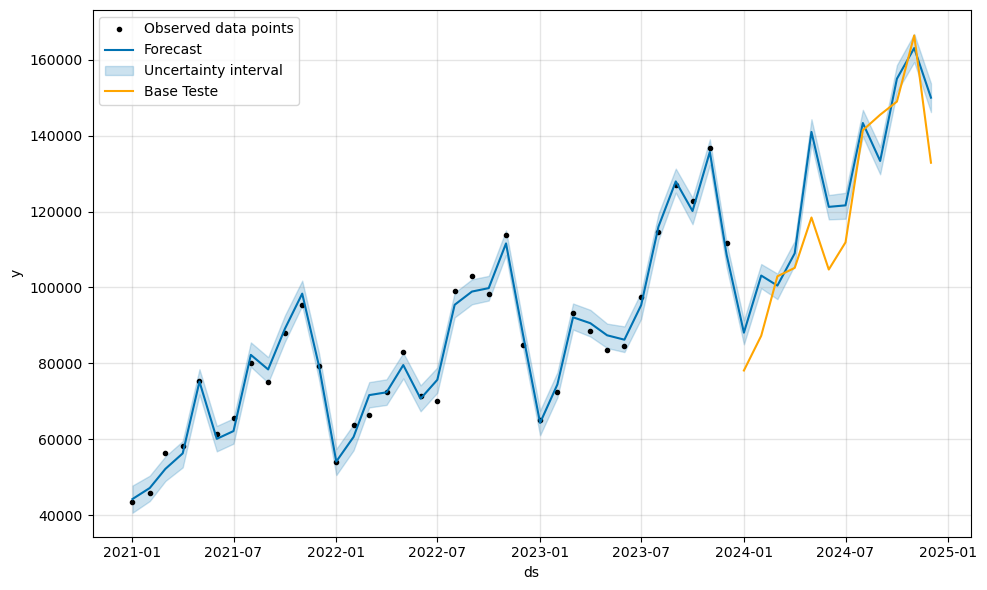

In [175]:
# model_Prof(future['yhat']

model_Prof.plot(future)
plt.plot(test, label='Base Teste', color="orange")
plt.legend()
plt.show()

In [177]:
from math import sqrt
from sklearn.metrics import mean_squared_error

In [179]:
Avaliar com as medidas de desempenho a escolha do melhor modelo

SyntaxError: invalid syntax (608011393.py, line 1)